# Exploratory Data Analysis — Synthetic Telecoms Complaints

**Purpose:** For synthetic data, standard EDA (missing values, outliers) is meaningless — we *designed* the data.  
Instead, this notebook answers three questions:

1. **Generation fidelity** — Did the LLM generator produce what we intended?  
2. **Lexical leakage** — Are there vocabulary shortcuts that let a bag-of-words model cheat?  
3. **Structural & embedding analysis** — Do text properties (length, embedding geometry) correlate with labels in ways that bypass genuine understanding?

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting defaults
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.titleweight": "bold",
})

# Colour palettes
URGENCY_PAL = {"Low": "#4CAF50", "Medium": "#FF9800", "High": "#F44336"}
EMOTION_PAL = {"Low": "#42A5F5", "Medium": "#AB47BC", "High": "#EF5350"}
URGENCY_ORDER = ["Low", "Medium", "High"]
EMOTION_ORDER = ["Low", "Medium", "High"]

# Paths
ROOT = Path("..").resolve()
DATA_PATH = ROOT / "data" / "telecoms_complaints.csv"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Figures saved to: {FIG_DIR.resolve()}")

Project root: /Users/uleso/Documents/UCL BA/nlp_urgency_ranking-main
Figures saved to: /Users/uleso/Documents/UCL BA/nlp_urgency_ranking-main/eda/figures


In [2]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(f"Dataset: {df.shape[0]:,} complaints, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head(3)

Dataset: 5,000 complaints, 8 columns
Columns: ['id', 'complaint_text', 'intended_urgency', 'intended_emotion', 'scenario', 'style', 'profile', 'history']


,id,complaint_text,intended_urgency,intended_emotion,scenario,style,profile,history
0,1,I reported very poor indoor signal at my flat ...,Low,Low,Poor Network Coverage,Terse and minimal,Vulnerable customer with disability or health ...,Second attempt — raised once before with no re...
1,2,I am the proprietor of a small café (account 0...,Low,Low,Difficulty Cancelling Service,Legalistic / rights-aware,Small business owner relying on service for li...,Second attempt — raised once before with no re...
2,3,So after six years with you I’m apparently bei...,Low,Low,Loyalty Penalty,Passive-aggressive / sarcastic,"Young professional, tech-savvy, impatient",First contact — raising the issue for the firs...


---
## 1. Generation Fidelity Audit

Verifying the synthetic pipeline produced data matching our design specifications:  
urgency skew (35/40/25%), uniform emotion, full metadata coverage, and affinity constraints.

### 1.1 Class Distribution — Marginals

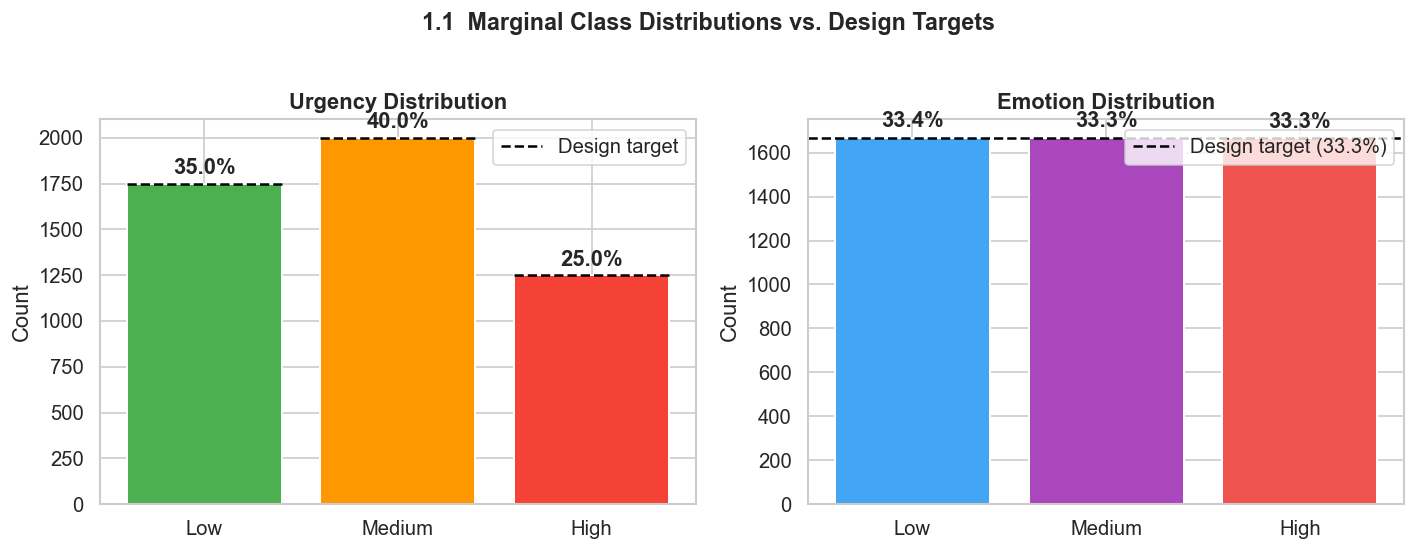

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Urgency ---
urg_counts = df["intended_urgency"].value_counts().reindex(URGENCY_ORDER)
urg_pct = urg_counts / len(df) * 100
bars = axes[0].bar(URGENCY_ORDER, urg_counts,
                   color=[URGENCY_PAL[u] for u in URGENCY_ORDER],
                   edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, urg_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Urgency Distribution")
axes[0].set_ylabel("Count")
# Design target lines
design_targets = {"Low": 0.35, "Medium": 0.40, "High": 0.25}
for level, target in design_targets.items():
    idx = URGENCY_ORDER.index(level)
    axes[0].hlines(target * len(df), idx - 0.4, idx + 0.4,
                   colors="black", linestyles="dashed", linewidth=1.5, label="Design target" if idx == 0 else "")
axes[0].legend(loc="upper right")

# --- Emotion ---
emo_counts = df["intended_emotion"].value_counts().reindex(EMOTION_ORDER)
emo_pct = emo_counts / len(df) * 100
bars = axes[1].bar(EMOTION_ORDER, emo_counts,
                   color=[EMOTION_PAL[e] for e in EMOTION_ORDER],
                   edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, emo_pct):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")
axes[1].set_title("Emotion Distribution")
axes[1].set_ylabel("Count")
axes[1].axhline(len(df) / 3, color="black", linestyle="dashed", linewidth=1.5, label="Design target (33.3%)")
axes[1].legend(loc="upper right")

fig.suptitle("1.1  Marginal Class Distributions vs. Design Targets", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "1_1_class_distributions.png", bbox_inches="tight")
plt.show()

### 1.2 Joint Urgency × Emotion Distribution (3×3 Grid)

Joint counts:


intended_emotion,Low,Medium,High,Total
intended_urgency,,,,
Low,584,583,583,1750
Medium,667,667,666,2000
High,417,417,416,1250
Total,1668,1667,1665,5000


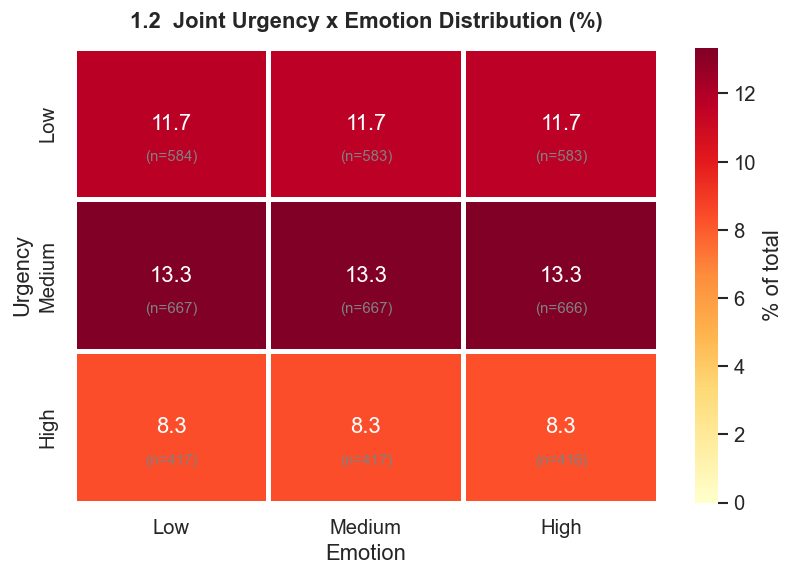

In [4]:
# Cross-tabulation
joint = pd.crosstab(df["intended_urgency"], df["intended_emotion"],
                    margins=True, margins_name="Total")
joint = joint.reindex(index=URGENCY_ORDER + ["Total"], columns=EMOTION_ORDER + ["Total"])
print("Joint counts:")
display(joint)

# Heatmap (without margins)
joint_core = joint.loc[URGENCY_ORDER, EMOTION_ORDER]
joint_pct = joint_core / len(df) * 100

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(joint_pct, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=2, linecolor="white", cbar_kws={"label": "% of total"},
            ax=ax, vmin=0)
# Overlay counts
for i, urg in enumerate(URGENCY_ORDER):
    for j, emo in enumerate(EMOTION_ORDER):
        count = joint_core.loc[urg, emo]
        ax.text(j + 0.5, i + 0.72, f"(n={count})", ha="center", va="center",
                fontsize=9, color="gray")

ax.set_title("1.2  Joint Urgency x Emotion Distribution (%)", fontweight="bold", pad=12)
ax.set_ylabel("Urgency")
ax.set_xlabel("Emotion")
fig.tight_layout()
fig.savefig(FIG_DIR / "1_2_joint_distribution.png", bbox_inches="tight")
plt.show()

### 1.3 Metadata Coverage — Scenarios, Styles, Profiles, History

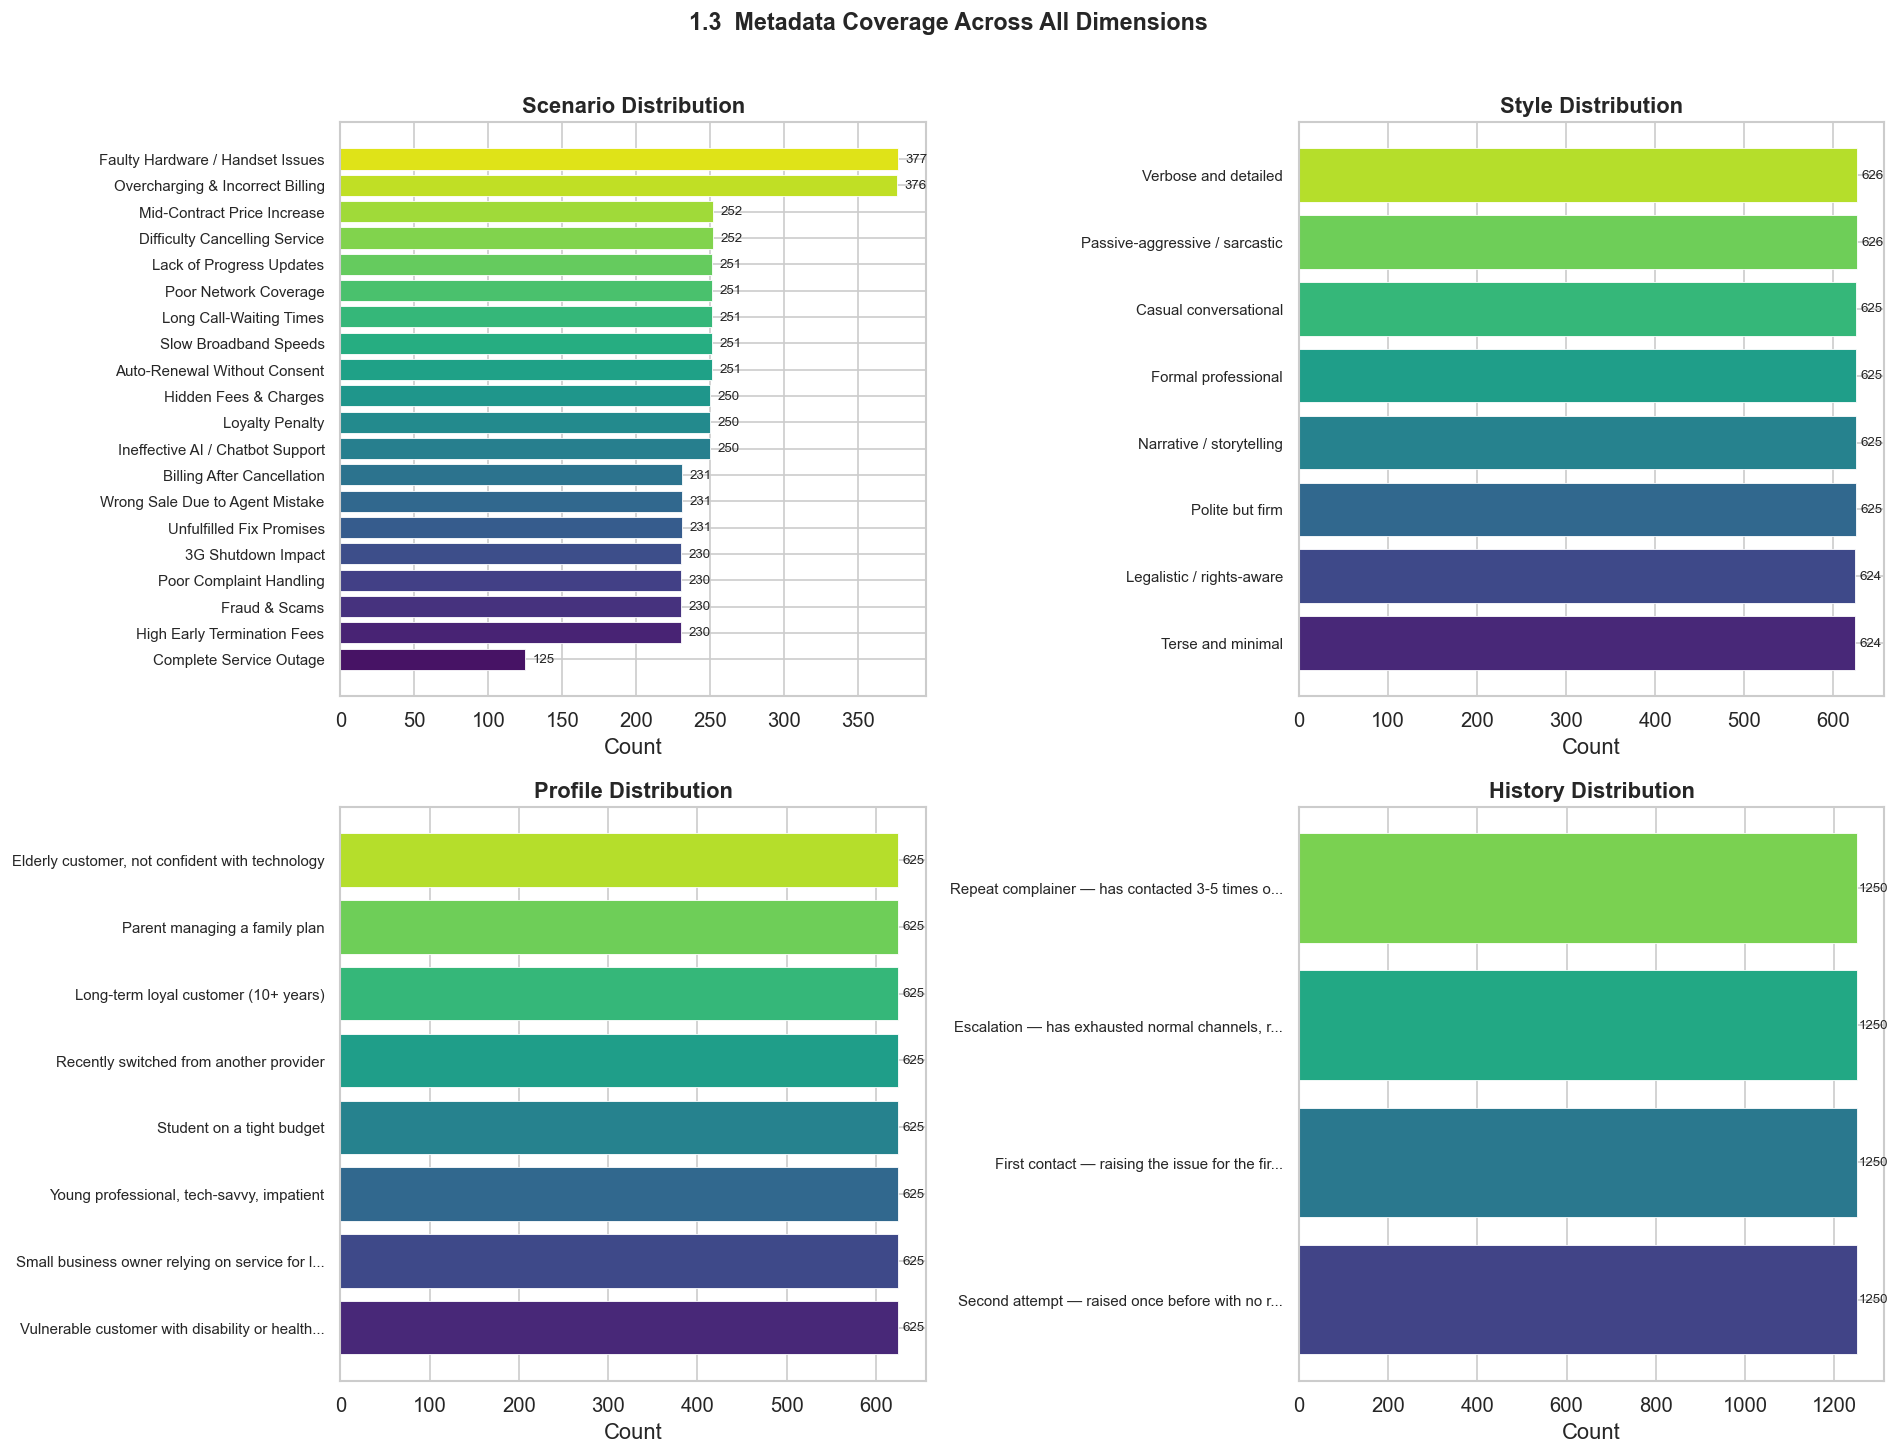

In [5]:
metadata_cols = ["scenario", "style", "profile", "history"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(metadata_cols):
    counts = df[col].value_counts().sort_values(ascending=True)
    short_labels = [s[:45] + "..." if len(s) > 48 else s for s in counts.index]
    
    bars = axes[idx].barh(range(len(counts)), counts.values,
                          color=sns.color_palette("viridis", len(counts)),
                          edgecolor="white", linewidth=0.5)
    axes[idx].set_yticks(range(len(counts)))
    axes[idx].set_yticklabels(short_labels, fontsize=9)
    axes[idx].set_xlabel("Count")
    axes[idx].set_title(f"{col.title()} Distribution", fontweight="bold")
    
    for bar, val in zip(bars, counts.values):
        axes[idx].text(val + 5, bar.get_y() + bar.get_height() / 2,
                       str(val), va="center", fontsize=8)

fig.suptitle("1.3  Metadata Coverage Across All Dimensions",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "1_3_metadata_coverage.png", bbox_inches="tight")
plt.show()

### 1.4 Scenario-Urgency Affinity Validation

The generation pipeline enforces constraints on which scenarios can appear at each urgency level (e.g., "Complete Service Outage" maps to High only). This heatmap verifies no violations occurred.

All scenario-urgency affinity constraints are satisfied.


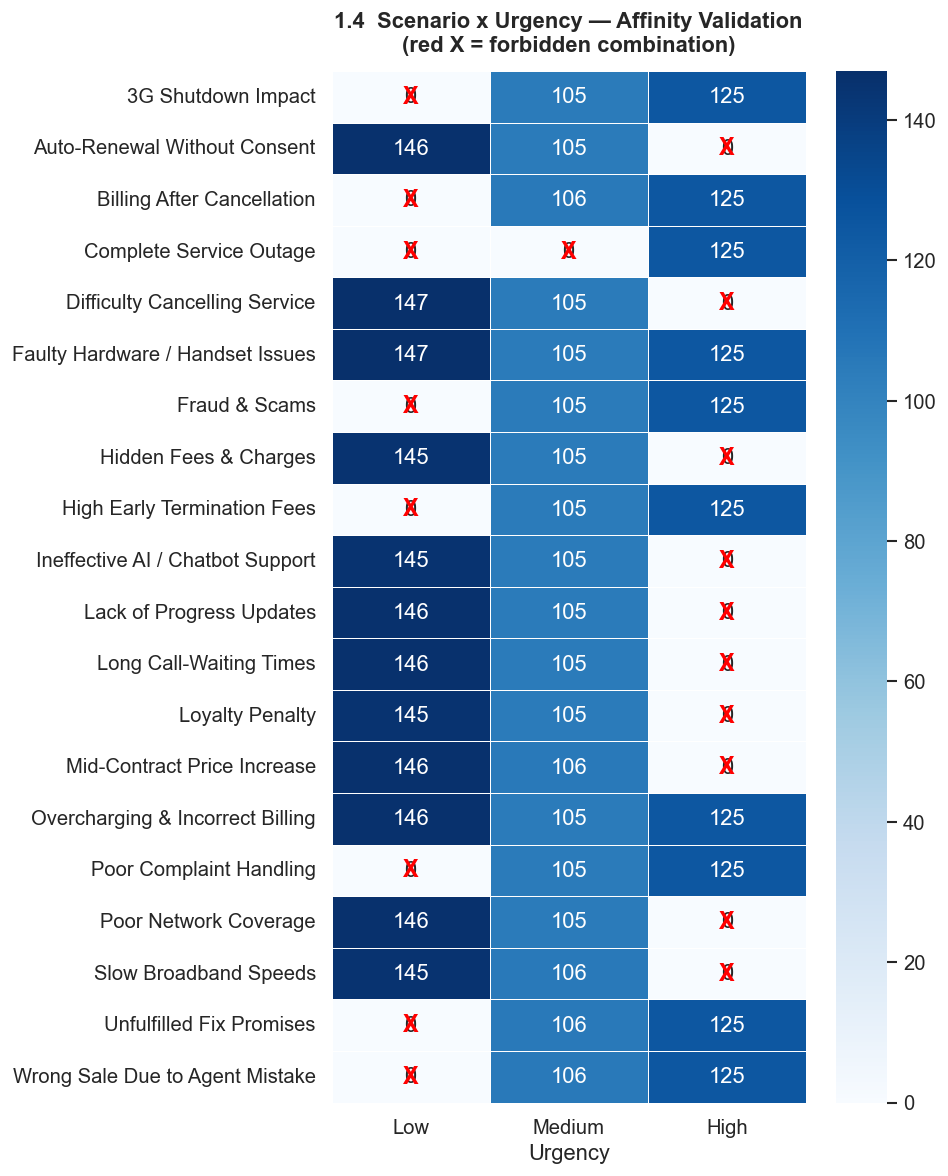

In [6]:
# Define the intended affinity constraints
SCENARIO_URGENCY = {
    "Difficulty Cancelling Service":       ["Low", "Medium"],
    "Fraud & Scams":                       ["Medium", "High"],
    "Overcharging & Incorrect Billing":    ["Low", "Medium", "High"],
    "Poor Network Coverage":               ["Low", "Medium"],
    "3G Shutdown Impact":                  ["Medium", "High"],
    "Auto-Renewal Without Consent":        ["Low", "Medium"],
    "Billing After Cancellation":          ["Medium", "High"],
    "High Early Termination Fees":         ["Medium", "High"],
    "Ineffective AI / Chatbot Support":    ["Low", "Medium"],
    "Unfulfilled Fix Promises":            ["Medium", "High"],
    "Long Call-Waiting Times":             ["Low", "Medium"],
    "Wrong Sale Due to Agent Mistake":     ["Medium", "High"],
    "Loyalty Penalty":                     ["Low", "Medium"],
    "Mid-Contract Price Increase":         ["Low", "Medium"],
    "Complete Service Outage":             ["High"],
    "Faulty Hardware / Handset Issues":    ["Low", "Medium", "High"],
    "Hidden Fees & Charges":               ["Low", "Medium"],
    "Lack of Progress Updates":            ["Low", "Medium"],
    "Poor Complaint Handling":             ["Medium", "High"],
    "Slow Broadband Speeds":               ["Low", "Medium"],
}

# Cross-tabulation: scenario x urgency
ct = pd.crosstab(df["scenario"], df["intended_urgency"])
ct = ct.reindex(columns=URGENCY_ORDER, fill_value=0)
ct = ct.sort_index()

# Build a mask: True where the combination should be ZERO (forbidden)
forbidden_mask = pd.DataFrame(False, index=ct.index, columns=ct.columns)
for scenario in ct.index:
    allowed = SCENARIO_URGENCY.get(scenario, URGENCY_ORDER)
    for urg in URGENCY_ORDER:
        if urg not in allowed:
            forbidden_mask.loc[scenario, urg] = True

# Check violations
violations = ct[forbidden_mask & (ct > 0)].stack()
violations = violations[violations > 0]

if len(violations) == 0:
    print("All scenario-urgency affinity constraints are satisfied.")
else:
    print(f"VIOLATIONS FOUND ({len(violations)}):")
    print(violations)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white", ax=ax)

# Mark forbidden cells with red X
for i, scenario in enumerate(ct.index):
    for j, urg in enumerate(ct.columns):
        if forbidden_mask.loc[scenario, urg]:
            ax.text(j + 0.5, i + 0.5, "X", ha="center", va="center",
                    fontsize=14, color="red", fontweight="bold")

ax.set_title("1.4  Scenario x Urgency — Affinity Validation\n(red X = forbidden combination)",
             fontweight="bold", pad=12)
ax.set_ylabel("")
ax.set_xlabel("Urgency")
fig.tight_layout()
fig.savefig(FIG_DIR / "1_4_scenario_urgency_affinity.png", bbox_inches="tight")
plt.show()

### 1.5 Style x Emotion Independence Check

After v3 data fixes, all 8 writing styles should be equally available at all emotion levels.  
We test this with a chi-squared test and visualise the normalised distribution.

Chi-squared test of independence: chi2=0.02, p=1.0000, dof=14
Result: INDEPENDENT (no leakage)


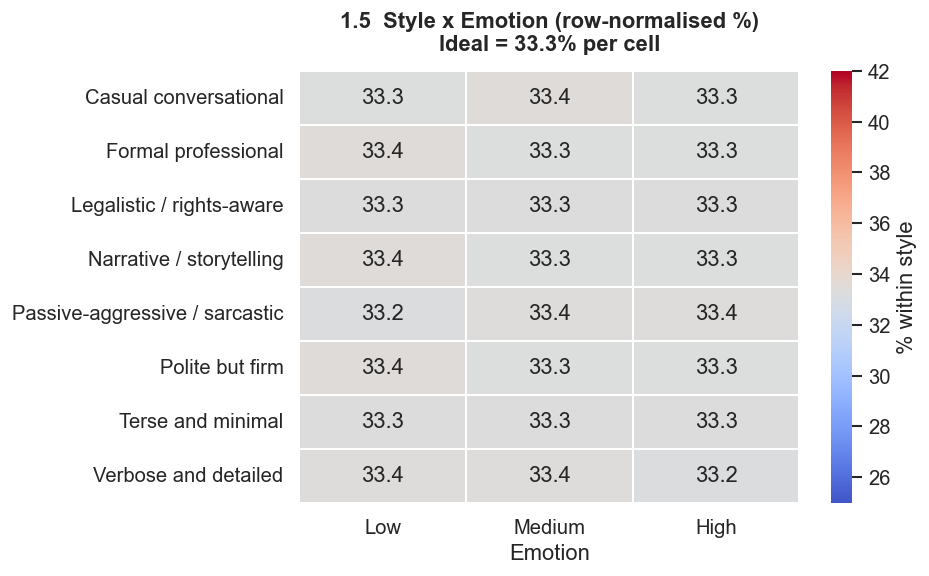

In [7]:
from scipy.stats import chi2_contingency

ct_style_emo = pd.crosstab(df["style"], df["intended_emotion"])
ct_style_emo = ct_style_emo.reindex(columns=EMOTION_ORDER)

chi2, p_val, dof, expected = chi2_contingency(ct_style_emo)
print(f"Chi-squared test of independence: chi2={chi2:.2f}, p={p_val:.4f}, dof={dof}")
print(f"Result: {'INDEPENDENT (no leakage)' if p_val > 0.05 else 'DEPENDENT — potential leakage detected'}")

# Normalised heatmap (row-normalised: each style sums to 100%)
ct_norm = ct_style_emo.div(ct_style_emo.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct_norm, annot=True, fmt=".1f", cmap="coolwarm",
            center=33.3, linewidths=1, linecolor="white",
            cbar_kws={"label": "% within style"}, ax=ax, vmin=25, vmax=42)
ax.set_title("1.5  Style x Emotion (row-normalised %)\nIdeal = 33.3% per cell",
             fontweight="bold", pad=12)
ax.set_ylabel("")
ax.set_xlabel("Emotion")
fig.tight_layout()
fig.savefig(FIG_DIR / "1_5_style_emotion_independence.png", bbox_inches="tight")
plt.show()

### 1.6 Profile x Urgency Independence Check

Customer profiles (e.g., "elderly", "student") should not predict urgency — otherwise the model learns demographic shortcuts.

Chi-squared test: chi2=8.32, p=0.8719, dof=14
Result: INDEPENDENT


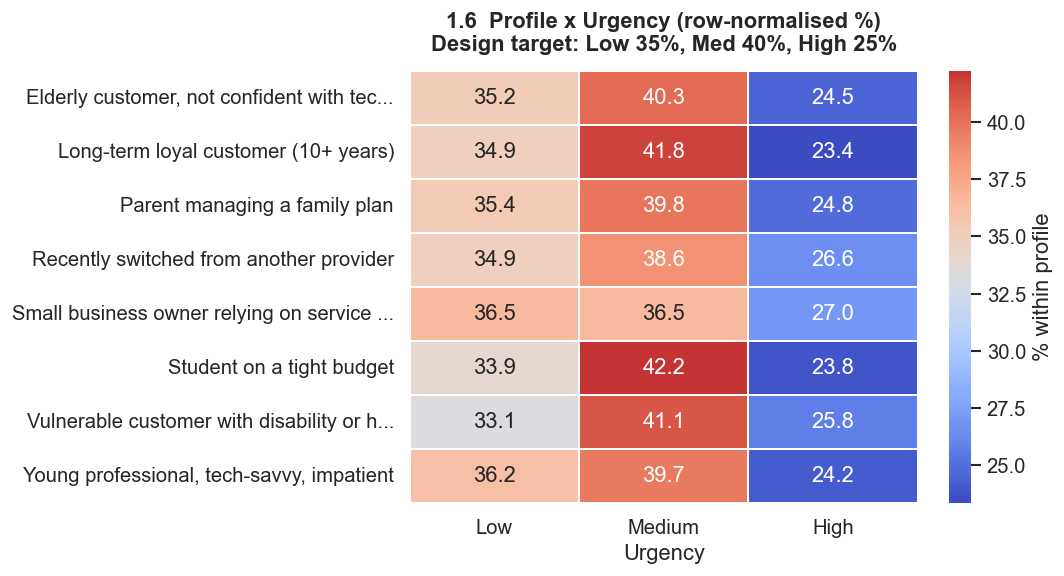

In [8]:
ct_prof_urg = pd.crosstab(df["profile"], df["intended_urgency"])
ct_prof_urg = ct_prof_urg.reindex(columns=URGENCY_ORDER)

chi2, p_val, dof, _ = chi2_contingency(ct_prof_urg)
print(f"Chi-squared test: chi2={chi2:.2f}, p={p_val:.4f}, dof={dof}")
print(f"Result: {'INDEPENDENT' if p_val > 0.05 else 'DEPENDENT — investigate'}")

ct_norm = ct_prof_urg.div(ct_prof_urg.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
short_labels = [p[:40] + "..." if len(p) > 43 else p for p in ct_norm.index]
sns.heatmap(ct_norm, annot=True, fmt=".1f", cmap="coolwarm",
            center=33.3, linewidths=1, linecolor="white",
            cbar_kws={"label": "% within profile"}, ax=ax,
            yticklabels=short_labels)
ax.set_title("1.6  Profile x Urgency (row-normalised %)\nDesign target: Low 35%, Med 40%, High 25%",
             fontweight="bold", pad=12)
ax.set_ylabel("")
ax.set_xlabel("Urgency")
fig.tight_layout()
fig.savefig(FIG_DIR / "1_6_profile_urgency_independence.png", bbox_inches="tight")
plt.show()

---
## 2. Lexical Leakage Detection

The most critical EDA for synthetic data. TF-IDF baseline outperforms fine-tuned DeBERTa on urgency (0.819 vs 0.801), suggesting the LLM generator embedded class-specific vocabulary shortcuts. This section exposes those patterns.

### 2.1 Top Discriminative Terms by Class (TF-IDF + Chi-Squared)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2 as sklearn_chi2
from sklearn.preprocessing import LabelEncoder

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                              min_df=5, sublinear_tf=True, stop_words="english")
X_tfidf = vectorizer.fit_transform(df["complaint_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

def top_chi2_terms(X, labels, class_order, feature_names, n=15):
    """Return top-N chi-squared terms per class."""
    le = LabelEncoder()
    y = le.fit_transform(labels)
    results = {}
    for cls_name in class_order:
        cls_idx = le.transform([cls_name])[0]
        y_binary = (y == cls_idx).astype(int)
        scores, _ = sklearn_chi2(X, y_binary)
        top_idx = np.argsort(scores)[-n:][::-1]
        results[cls_name] = list(zip(feature_names[top_idx], scores[top_idx]))
    return results

urg_terms = top_chi2_terms(X_tfidf, df["intended_urgency"], URGENCY_ORDER, feature_names, n=15)
emo_terms = top_chi2_terms(X_tfidf, df["intended_emotion"], EMOTION_ORDER, feature_names, n=15)

print("Top 15 discriminative terms per urgency level:")
print("=" * 70)
for level, terms in urg_terms.items():
    term_list = ", ".join([f"{t[0]} ({t[1]:.0f})" for t in terms[:10]])
    print(f"\n{level}: {term_list}")

Top 15 discriminative terms per urgency level:

Low: wait (25), 3g (14), wait proper (13), wait days (13), hours (12), 24 hours (12), lost (11), fraud (11), immediately (11), 14 days (10)

Medium: working days (25), days (16), seven days (14), working (13), emergency (11), 24 hours (11), seven (11), wait (9), risk (7), visit working (6)

High: 24 hours (57), risk (38), today (31), safety (29), outage (28), alarm (27), hours (26), financial (26), immediate (23), emergency services (21)


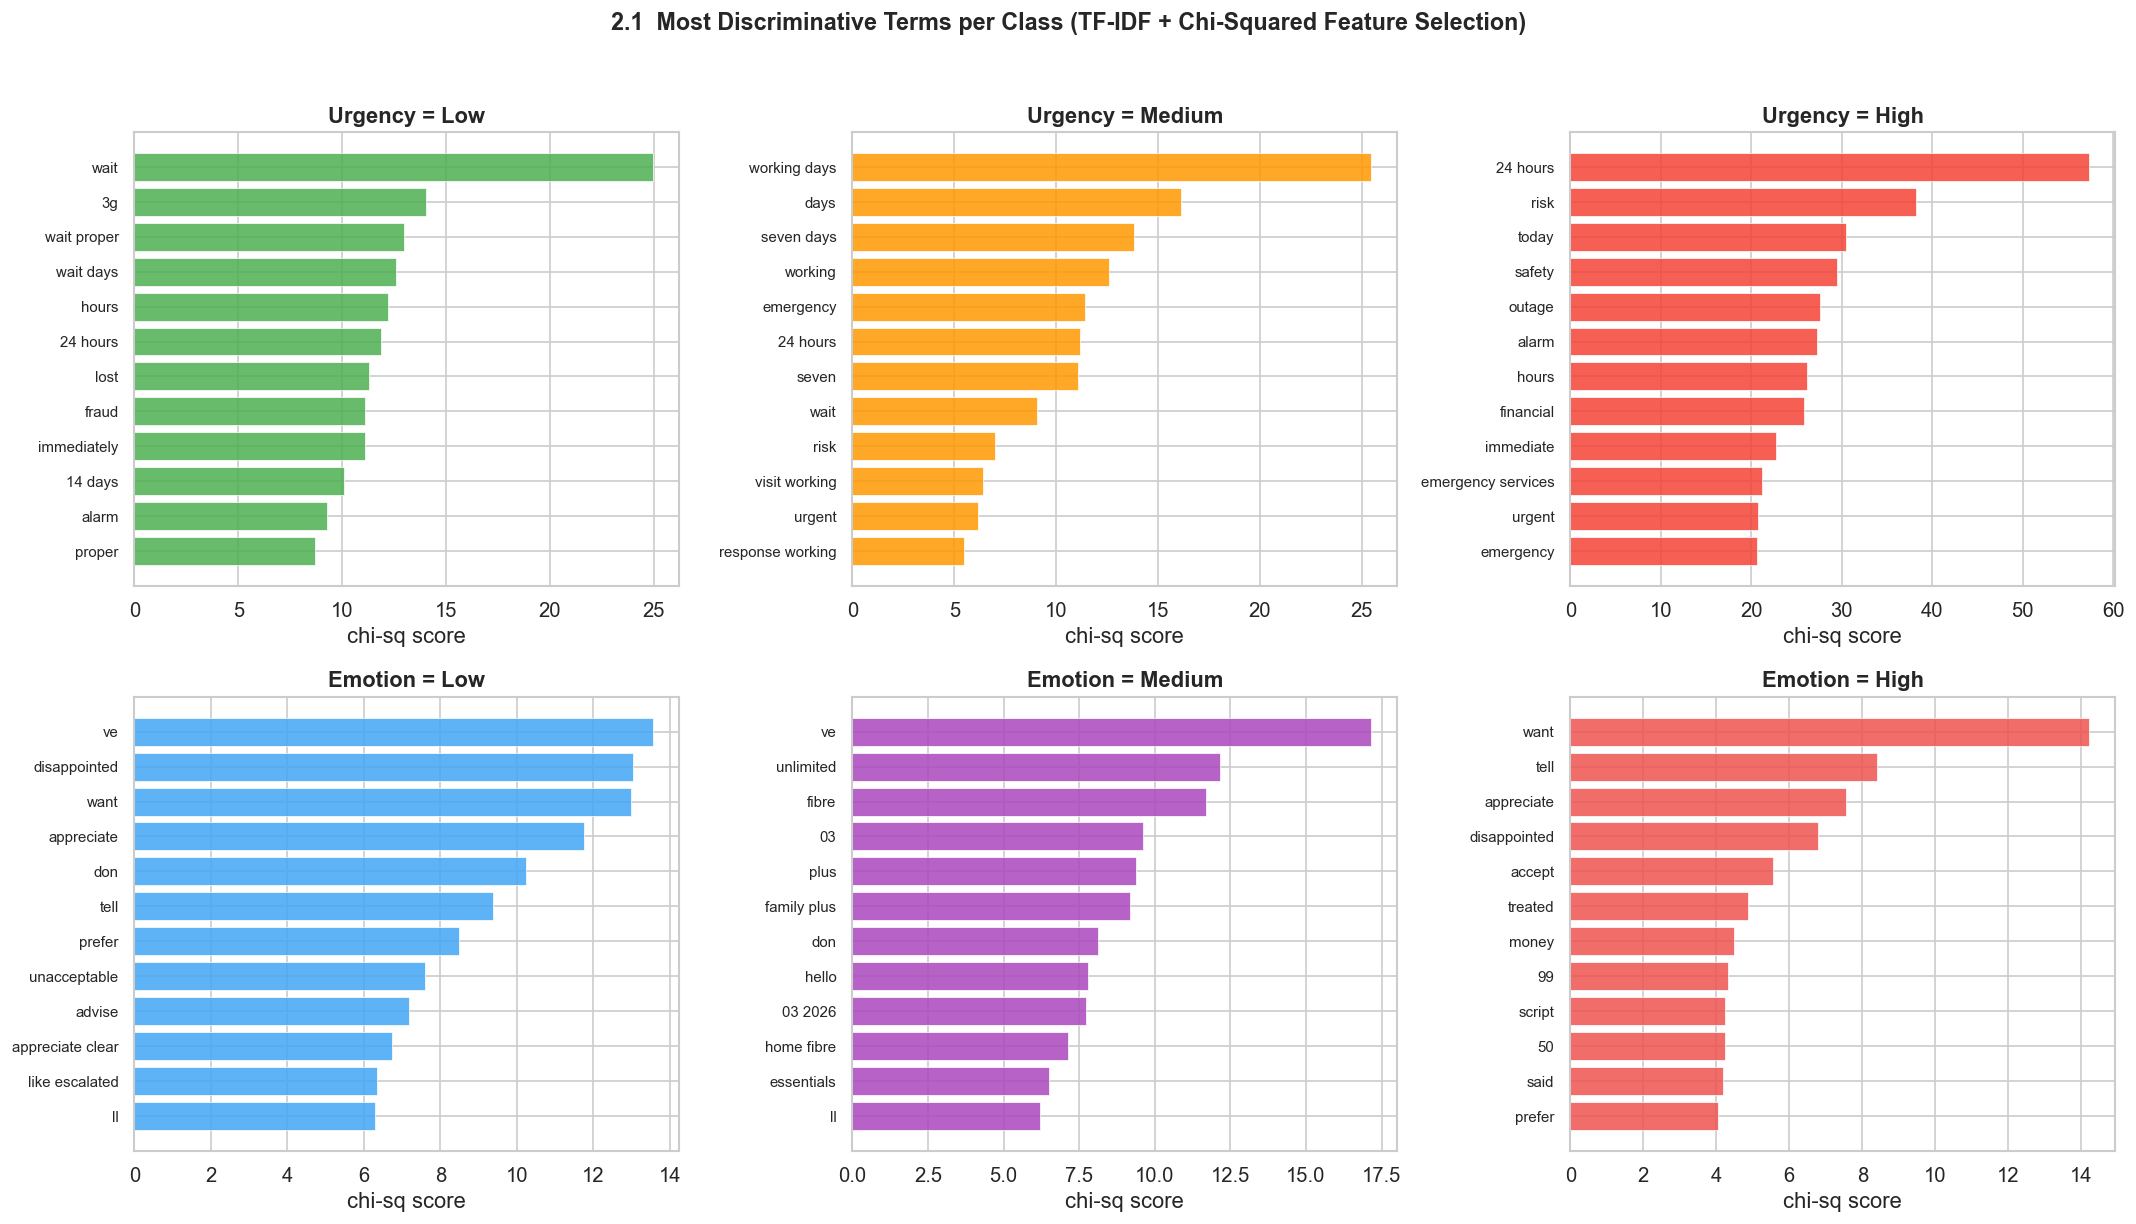

In [10]:
# Visualise top discriminative terms
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (terms_dict, label_name, palette, order) in enumerate([
    (urg_terms, "Urgency", URGENCY_PAL, URGENCY_ORDER),
    (emo_terms, "Emotion", EMOTION_PAL, EMOTION_ORDER),
]):
    for row_idx, level in enumerate(order):
        ax = axes[col_idx, row_idx]
        terms = terms_dict[level][:12]
        words = [t[0] for t in terms][::-1]
        scores = [t[1] for t in terms][::-1]
        
        ax.barh(range(len(words)), scores, color=palette[level],
                edgecolor="white", linewidth=0.5, alpha=0.85)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=9)
        ax.set_title(f"{label_name} = {level}", fontweight="bold")
        ax.set_xlabel("chi-sq score")

fig.suptitle("2.1  Most Discriminative Terms per Class (TF-IDF + Chi-Squared Feature Selection)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "2_1_discriminative_terms.png", bbox_inches="tight")
plt.show()

### 2.2 Vocabulary Overlap Between Classes

If classes share little vocabulary, the task is artificially easy for bag-of-words models.  
We measure the Jaccard similarity of top-500 TF-IDF terms per class.

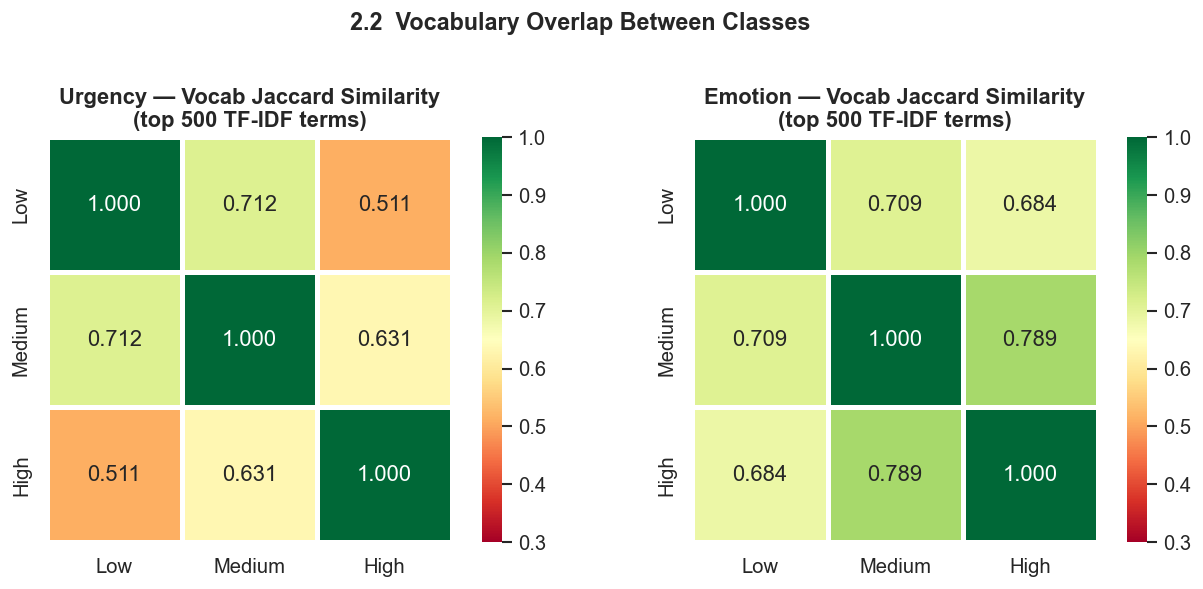

Urgency — avg Jaccard overlap: 0.618
  Low vs Medium: 0.712
  Low vs High: 0.511
  Medium vs High: 0.631
Emotion — avg Jaccard overlap: 0.727
  Low vs Medium: 0.709
  Low vs High: 0.684
  Medium vs High: 0.789


In [11]:
def get_top_vocab(texts, n=500):
    """Return top-N TF-IDF terms for a set of texts."""
    vec = TfidfVectorizer(max_features=n, stop_words="english", sublinear_tf=True)
    vec.fit(texts)
    return set(vec.get_feature_names_out())

def jaccard(set_a, set_b):
    return len(set_a & set_b) / len(set_a | set_b)

urg_vocabs = {level: get_top_vocab(df[df["intended_urgency"] == level]["complaint_text"])
              for level in URGENCY_ORDER}
emo_vocabs = {level: get_top_vocab(df[df["intended_emotion"] == level]["complaint_text"])
              for level in EMOTION_ORDER}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, vocabs, title, order in [
    (axes[0], urg_vocabs, "Urgency", URGENCY_ORDER),
    (axes[1], emo_vocabs, "Emotion", EMOTION_ORDER),
]:
    sim_matrix = pd.DataFrame(
        [[jaccard(vocabs[a], vocabs[b]) for b in order] for a in order],
        index=order, columns=order
    )
    sns.heatmap(sim_matrix, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0.3, vmax=1.0, linewidths=2, linecolor="white",
                ax=ax, square=True)
    ax.set_title(f"{title} — Vocab Jaccard Similarity\n(top 500 TF-IDF terms)", fontweight="bold")

fig.suptitle("2.2  Vocabulary Overlap Between Classes", fontsize=14, fontweight="bold", y=1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "2_2_vocabulary_overlap.png", bbox_inches="tight")
plt.show()

# Summary
for name, vocabs, order in [("Urgency", urg_vocabs, URGENCY_ORDER), ("Emotion", emo_vocabs, EMOTION_ORDER)]:
    pairs = [(a, b, jaccard(vocabs[a], vocabs[b]))
             for i, a in enumerate(order) for b in order[i+1:]]
    avg_jaccard = np.mean([p[2] for p in pairs])
    print(f"{name} — avg Jaccard overlap: {avg_jaccard:.3f}")
    for a, b, j in pairs:
        print(f"  {a} vs {b}: {j:.3f}")

### 2.3 Class-Exclusive Terms

Terms that appear **only** in one class are the strongest leakage signal — a model can classify perfectly just by detecting their presence.

In [12]:
def find_exclusive_terms(vocabs, order):
    """Find terms unique to each class (not in any other class's top-500)."""
    results = {}
    for level in order:
        others = set()
        for other_level in order:
            if other_level != level:
                others |= vocabs[other_level]
        exclusive = vocabs[level] - others
        results[level] = sorted(exclusive)
    return results

urg_exclusive = find_exclusive_terms(urg_vocabs, URGENCY_ORDER)
emo_exclusive = find_exclusive_terms(emo_vocabs, EMOTION_ORDER)

print("URGENCY — Class-exclusive terms (top-500 vocab):")
print("=" * 60)
for level, terms in urg_exclusive.items():
    print(f"\n{level} ({len(terms)} exclusive terms):")
    print(f"  {', '.join(terms[:25])}{'...' if len(terms) > 25 else ''}")

print("\n")
print("EMOTION — Class-exclusive terms (top-500 vocab):")
print("=" * 60)
for level, terms in emo_exclusive.items():
    print(f"\n{level} ({len(terms)} exclusive terms):")
    print(f"  {', '.join(terms[:25])}{'...' if len(terms) > 25 else ''}")

URGENCY — Class-exclusive terms (top-500 vocab):

Low (76 exclusive terms):
  2025, acknowledgement, actually, add, answer, apps, assistant, automatic, battery, better, checked, clarity, clearly, communication, consistently, dates, difference, difficult, does, download, emailed, estimated, explicit, form, forward...

Medium (27 exclusive terms):
  27, 31, 49, 72, affecting, apply, appointments, bills, booked, exit, health, intermittently, later, level, ll, ongoing, outcome, paid, rata, remove, saying, stable, text, timetable, unreliable...

High (105 exclusive terms):
  07, 200, ability, actions, activity, aisha, alarm, arranged, authorised, away, breach, carer, carers, caused, close, collection, compatible, complete, completely, connectivity, contacts, continued, corrective, critical, daniel...


EMOTION — Class-exclusive terms (top-500 vocab):

Low (65 exclusive terms):
  2025, 27, acknowledgement, active, advised, adviser, advisors, affecting, agreement, appears, appreciated, arrang

---
## 3. Text Structure Analysis

Investigating whether structural text properties (length, sentence count) correlate with labels — another form of shortcut the model could exploit.

### 3.1 Word Count Distribution by Class

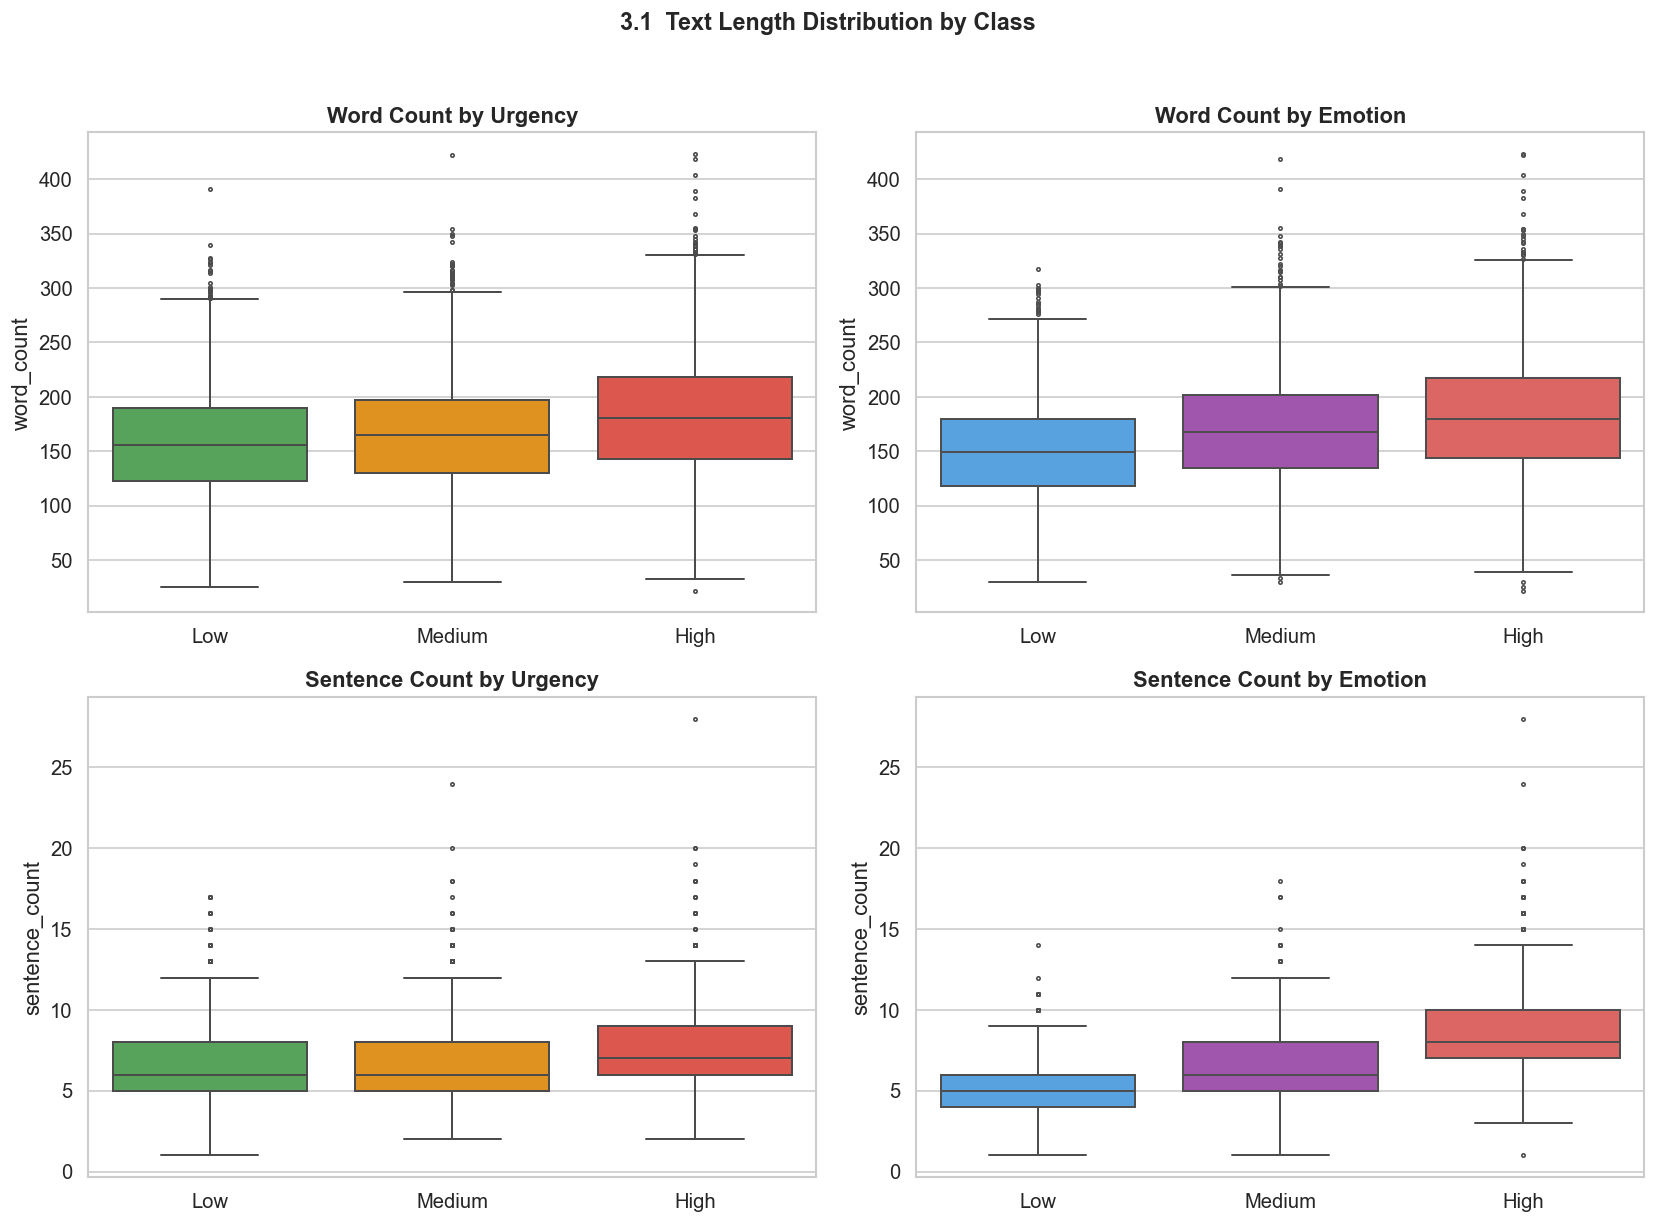


Word count statistics by urgency:


,count,mean,std,min,25%,50%,75%,max
intended_urgency,,,,,,,,
Low,1750.0,156.6,54.5,25.0,123.0,156.0,190.0,391.0
Medium,2000.0,164.1,55.4,30.0,130.0,165.0,197.0,422.0
High,1250.0,181.0,62.8,22.0,143.0,181.0,218.0,423.0



Word count statistics by emotion:


,count,mean,std,min,25%,50%,75%,max
intended_emotion,,,,,,,,
Low,1668.0,149.3,49.2,30.0,118.0,149.0,180.0,318.0
Medium,1667.0,166.8,57.2,30.0,135.0,168.0,201.5,419.0
High,1665.0,181.0,61.9,22.0,144.0,180.0,217.0,423.0


In [13]:
df["word_count"] = df["complaint_text"].str.split().str.len()
df["char_count"] = df["complaint_text"].str.len()
df["sentence_count"] = df["complaint_text"].str.count(r'[.!?]+\s')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x="intended_urgency", y="word_count",
            order=URGENCY_ORDER, palette=URGENCY_PAL, ax=axes[0, 0],
            fliersize=2, linewidth=1.2)
axes[0, 0].set_title("Word Count by Urgency", fontweight="bold")
axes[0, 0].set_xlabel("")

sns.boxplot(data=df, x="intended_emotion", y="word_count",
            order=EMOTION_ORDER, palette=EMOTION_PAL, ax=axes[0, 1],
            fliersize=2, linewidth=1.2)
axes[0, 1].set_title("Word Count by Emotion", fontweight="bold")
axes[0, 1].set_xlabel("")

sns.boxplot(data=df, x="intended_urgency", y="sentence_count",
            order=URGENCY_ORDER, palette=URGENCY_PAL, ax=axes[1, 0],
            fliersize=2, linewidth=1.2)
axes[1, 0].set_title("Sentence Count by Urgency", fontweight="bold")
axes[1, 0].set_xlabel("")

sns.boxplot(data=df, x="intended_emotion", y="sentence_count",
            order=EMOTION_ORDER, palette=EMOTION_PAL, ax=axes[1, 1],
            fliersize=2, linewidth=1.2)
axes[1, 1].set_title("Sentence Count by Emotion", fontweight="bold")
axes[1, 1].set_xlabel("")

fig.suptitle("3.1  Text Length Distribution by Class", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "3_1_text_length_by_class.png", bbox_inches="tight")
plt.show()

print("\nWord count statistics by urgency:")
display(df.groupby("intended_urgency")["word_count"].describe().reindex(URGENCY_ORDER).round(1))
print("\nWord count statistics by emotion:")
display(df.groupby("intended_emotion")["word_count"].describe().reindex(EMOTION_ORDER).round(1))

### 3.2 Statistical Test — Is Text Length a Confound?

In [14]:
from scipy.stats import kruskal

for target, order in [("intended_urgency", URGENCY_ORDER), ("intended_emotion", EMOTION_ORDER)]:
    groups = [df[df[target] == level]["word_count"].values for level in order]
    stat, p = kruskal(*groups)
    effect = "SIGNIFICANT" if p < 0.05 else "NOT significant"
    print(f"{target}: H={stat:.2f}, p={p:.4e} — {effect}")
    
    n = len(df)
    k = len(order)
    eps_sq = (stat - k + 1) / (n - k)
    size_label = "negligible" if eps_sq < 0.01 else "small" if eps_sq < 0.06 else "medium" if eps_sq < 0.14 else "large"
    print(f"  Effect size (epsilon-sq): {eps_sq:.4f} ({size_label})")
    print()

intended_urgency: H=131.76, p=2.4522e-29 — SIGNIFICANT
  Effect size (epsilon-sq): 0.0260 (small)

intended_emotion: H=265.38, p=2.3672e-58 — SIGNIFICANT
  Effect size (epsilon-sq): 0.0527 (small)



### 3.3 Token Length Distribution & Truncation Analysis

The model uses `max_length=192` tokens. Complaints exceeding this are truncated, potentially losing critical information. We approximate token counts using whitespace splitting with a 1.3x multiplier (typical for subword tokenisers) to avoid heavy model downloads.

Approx token count: mean=217, median=216, max=551
Estimated truncated at 192 tokens: 3212 (64.2%)


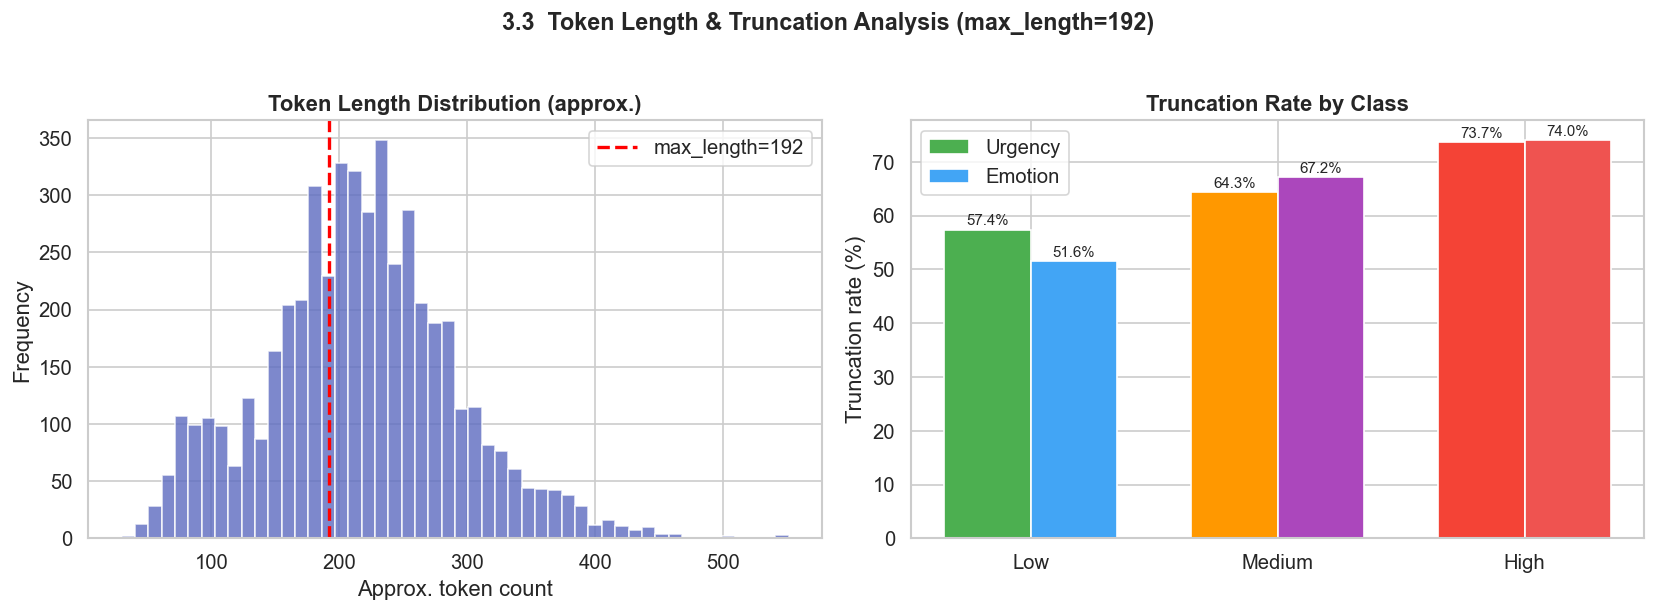

In [15]:
# Approximate token count using word count * 1.3 (typical subword expansion ratio)
# DeBERTa-v3-base uses SentencePiece; empirically ~1.3 tokens per whitespace word for English
SUBWORD_RATIO = 1.3
df["approx_token_count"] = (df["word_count"] * SUBWORD_RATIO + 2).astype(int)  # +2 for [CLS] and [SEP]

MAX_LENGTH = 192
df["truncated"] = df["approx_token_count"] > MAX_LENGTH

print(f"Approx token count: mean={df['approx_token_count'].mean():.0f}, "
      f"median={df['approx_token_count'].median():.0f}, "
      f"max={df['approx_token_count'].max()}")
print(f"Estimated truncated at {MAX_LENGTH} tokens: {df['truncated'].sum()} "
      f"({df['truncated'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token distribution histogram
axes[0].hist(df["approx_token_count"], bins=50, color="#5C6BC0", edgecolor="white", alpha=0.8)
axes[0].axvline(MAX_LENGTH, color="red", linestyle="--", linewidth=2, label=f"max_length={MAX_LENGTH}")
axes[0].set_xlabel("Approx. token count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Token Length Distribution (approx.)", fontweight="bold")
axes[0].legend()

# Truncation rate by class
trunc_by_urg = df.groupby("intended_urgency")["truncated"].mean().reindex(URGENCY_ORDER) * 100
trunc_by_emo = df.groupby("intended_emotion")["truncated"].mean().reindex(EMOTION_ORDER) * 100

x = np.arange(3)
width = 0.35
bars1 = axes[1].bar(x - width/2, trunc_by_urg.values, width,
                     label="Urgency", color=[URGENCY_PAL[u] for u in URGENCY_ORDER],
                     edgecolor="white")
bars2 = axes[1].bar(x + width/2, trunc_by_emo.values, width,
                     label="Emotion", color=[EMOTION_PAL[e] for e in EMOTION_ORDER],
                     edgecolor="white")

axes[1].set_xticks(x)
axes[1].set_xticklabels(["Low", "Medium", "High"])
axes[1].set_ylabel("Truncation rate (%)")
axes[1].set_title("Truncation Rate by Class", fontweight="bold")
axes[1].legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.1:
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                         f"{h:.1f}%", ha="center", va="bottom", fontsize=9)

fig.suptitle("3.3  Token Length & Truncation Analysis (max_length=192)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "3_3_token_truncation.png", bbox_inches="tight")
plt.show()

---
## 4. Embedding Space Analysis

Visualising how complaints cluster in semantic space *before* fine-tuning using t-SNE on TF-IDF representations.  
If classes are well-separated before fine-tuning, the task may be too easy.  
If they overlap, fine-tuning is justified.

### 4.1 t-SNE Projection of TF-IDF Representations

In [16]:
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

# Reduce TF-IDF to 50 dims with SVD first (t-SNE is slow on high-dim sparse data)
print("Reducing dimensionality: TF-IDF (10000-d) -> SVD (50-d) -> t-SNE (2-d)...")
svd = TruncatedSVD(n_components=50, random_state=SEED)
X_svd = svd.fit_transform(X_tfidf)
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.1%}")

# t-SNE on the 50-d SVD representation
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000, init="pca")
X_2d = tsne.fit_transform(X_svd)
df["tsne_x"] = X_2d[:, 0]
df["tsne_y"] = X_2d[:, 1]
print("Done.")

Reducing dimensionality: TF-IDF (10000-d) -> SVD (50-d) -> t-SNE (2-d)...
SVD explained variance: 12.5%
Done.


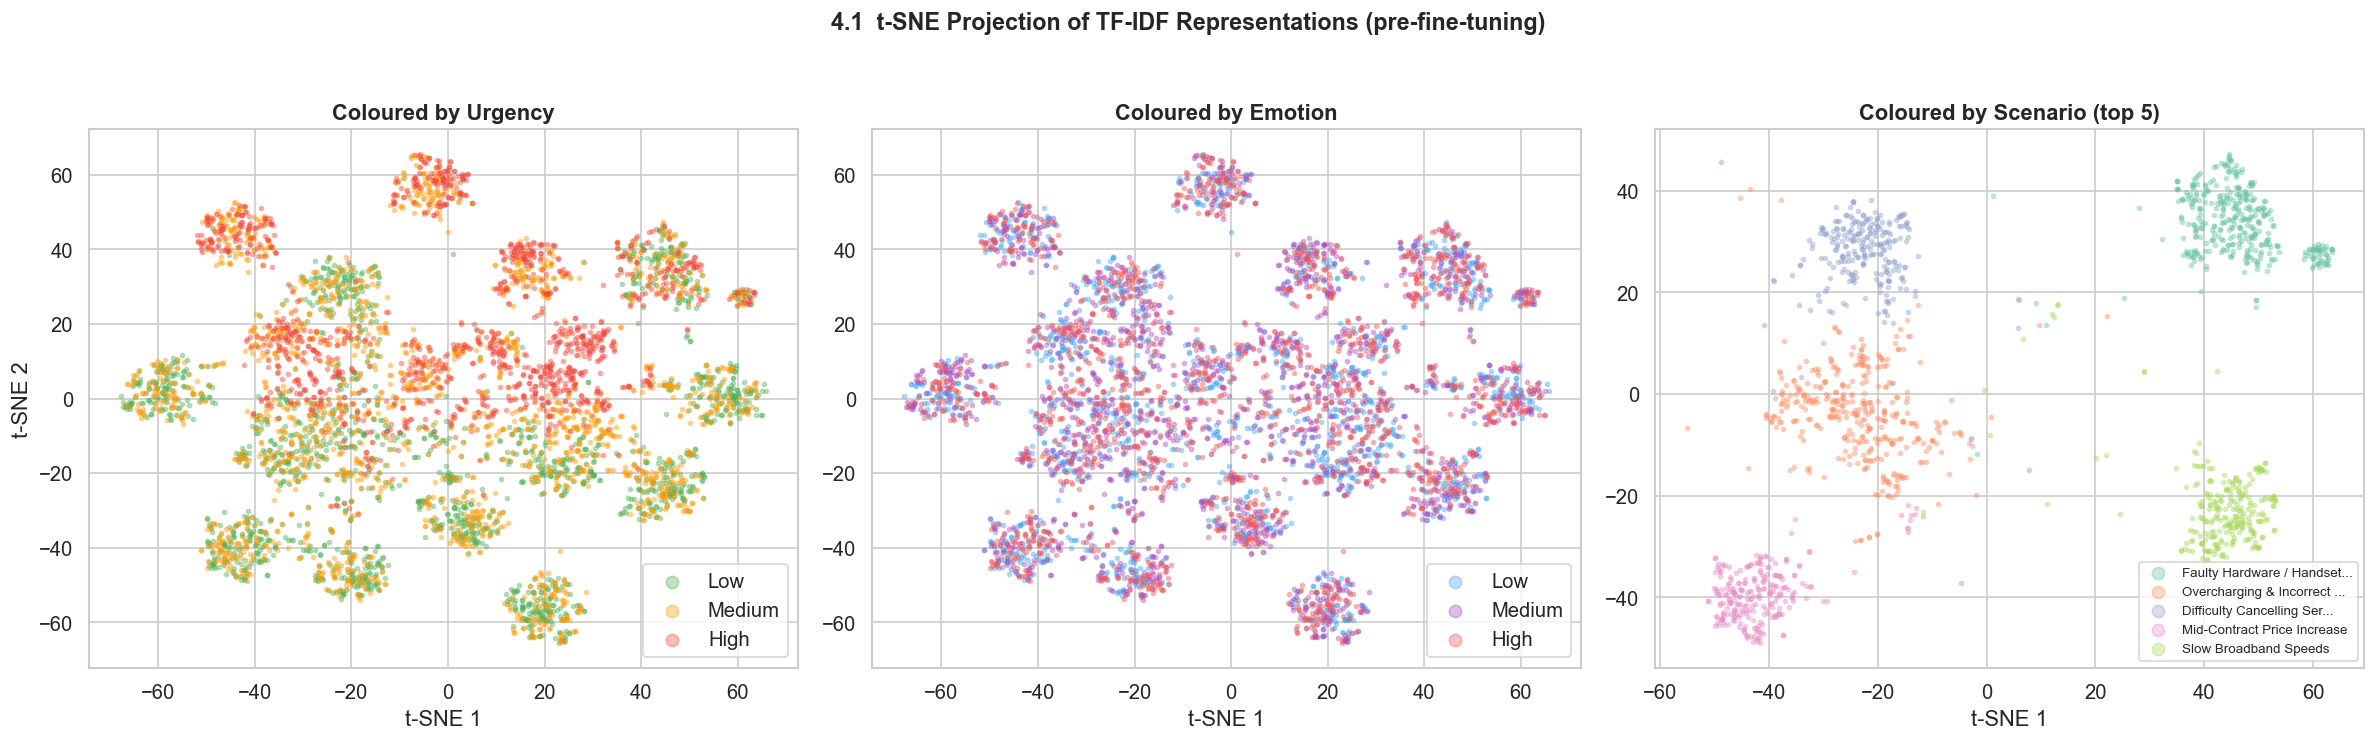

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Coloured by urgency
for level in URGENCY_ORDER:
    mask = df["intended_urgency"] == level
    axes[0].scatter(df.loc[mask, "tsne_x"], df.loc[mask, "tsne_y"],
                    c=URGENCY_PAL[level], label=level, s=6, alpha=0.35)
axes[0].set_title("Coloured by Urgency", fontweight="bold")
axes[0].legend(markerscale=3)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# Coloured by emotion
for level in EMOTION_ORDER:
    mask = df["intended_emotion"] == level
    axes[1].scatter(df.loc[mask, "tsne_x"], df.loc[mask, "tsne_y"],
                    c=EMOTION_PAL[level], label=level, s=6, alpha=0.35)
axes[1].set_title("Coloured by Emotion", fontweight="bold")
axes[1].legend(markerscale=3)
axes[1].set_xlabel("t-SNE 1")

# Coloured by scenario (top 5 for readability)
top_scenarios = df["scenario"].value_counts().head(5).index.tolist()
scenario_pal = dict(zip(top_scenarios, sns.color_palette("Set2", 5)))
for scenario in top_scenarios:
    mask = df["scenario"] == scenario
    short = scenario[:25] + "..." if len(scenario) > 28 else scenario
    axes[2].scatter(df.loc[mask, "tsne_x"], df.loc[mask, "tsne_y"],
                    c=[scenario_pal[scenario]], label=short, s=6, alpha=0.35)
axes[2].set_title("Coloured by Scenario (top 5)", fontweight="bold")
axes[2].legend(markerscale=3, fontsize=8)
axes[2].set_xlabel("t-SNE 1")

fig.suptitle("4.1  t-SNE Projection of TF-IDF Representations (pre-fine-tuning)",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "4_1_tsne_tfidf.png", bbox_inches="tight")
plt.show()

### 4.2 Cluster Separability by Label Type (Silhouette Score)

Silhouette score quantifies how well each label type defines distinct clusters in the TF-IDF feature space. If *scenario* scores highest, the model may learn scenario-to-label mappings rather than genuine urgency/emotion signals.

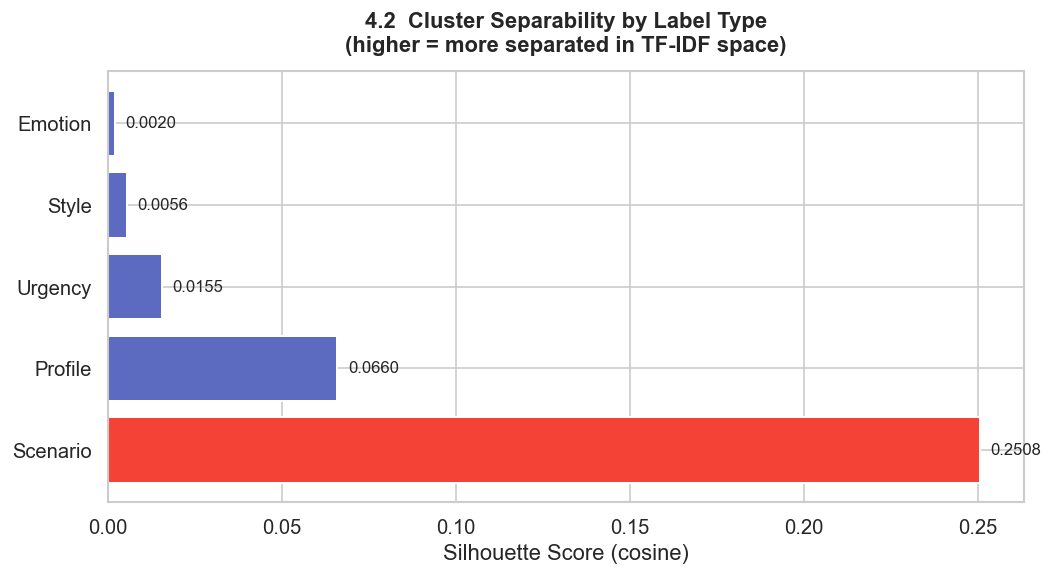


Dominant clustering dimension: scenario
This explains why TF-IDF (which captures scenario keywords) outperforms DeBERTa on urgency.


In [18]:
from sklearn.metrics import silhouette_score

le = LabelEncoder()
results_sil = {}
for col in ["intended_urgency", "intended_emotion", "scenario", "style", "profile"]:
    labels = le.fit_transform(df[col])
    score = silhouette_score(X_svd, labels, metric="cosine", sample_size=2000,
                              random_state=SEED)
    results_sil[col] = score

fig, ax = plt.subplots(figsize=(9, 5))
labels_sorted = sorted(results_sil.keys(), key=lambda k: results_sil[k], reverse=True)
scores_sorted = [results_sil[k] for k in labels_sorted]
display_names = [l.replace("intended_", "").title() for l in labels_sorted]

colors = ["#F44336" if s == max(scores_sorted) else "#5C6BC0" for s in scores_sorted]
bars = ax.barh(range(len(labels_sorted)), scores_sorted, color=colors,
               edgecolor="white", linewidth=1.2)
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(display_names)
ax.set_xlabel("Silhouette Score (cosine)")
ax.set_title("4.2  Cluster Separability by Label Type\n(higher = more separated in TF-IDF space)",
             fontweight="bold", pad=12)

for bar, score in zip(bars, scores_sorted):
    ax.text(score + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}", va="center", fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / "4_2_silhouette_by_label.png", bbox_inches="tight")
plt.show()

dominant = labels_sorted[0].replace("intended_", "")
print(f"\nDominant clustering dimension: {dominant}")
if dominant == "scenario":
    print("WARNING: Scenario clusters dominate — model may use scenario as a proxy for urgency.")
    print("This explains why TF-IDF (which captures scenario keywords) outperforms DeBERTa on urgency.")

---
## 5. Summary of Findings

In [19]:
print("=" * 70)
print("EDA SUMMARY — Synthetic Telecoms Complaints Dataset")
print("=" * 70)

print(f"\n--- Dataset Overview ---")
print(f"Total complaints: {len(df):,}")
print(f"Urgency distribution: Low={urg_pct['Low']:.1f}%, Med={urg_pct['Medium']:.1f}%, High={urg_pct['High']:.1f}%")
print(f"Emotion distribution: ~{100/3:.1f}% each (uniform by design)")
print(f"Metadata: {df['scenario'].nunique()} scenarios, {df['style'].nunique()} styles, "
      f"{df['profile'].nunique()} profiles, {df['history'].nunique()} history levels")

print(f"\n--- 1. Generation Fidelity ---")
print(f"Class distributions match design targets: YES")
print(f"Scenario-urgency affinity violations: {len(violations) if len(violations) > 0 else 'NONE'}")
print(f"All metadata categories represented: YES")

print(f"\n--- 2. Lexical Leakage ---")
for name, vocabs, order in [("Urgency", urg_vocabs, URGENCY_ORDER), ("Emotion", emo_vocabs, EMOTION_ORDER)]:
    pairs = [(a, b, jaccard(vocabs[a], vocabs[b]))
             for i, a in enumerate(order) for b in order[i+1:]]
    avg_j = np.mean([p[2] for p in pairs])
    print(f"{name} vocab overlap (Jaccard): {avg_j:.3f}")
    exc = find_exclusive_terms(vocabs, order)
    total_exc = sum(len(v) for v in exc.values())
    print(f"  Exclusive terms: {total_exc} across all classes")

print(f"\n--- 3. Structural Confounds ---")
print(f"Mean word count: {df['word_count'].mean():.0f} (range: {df['word_count'].min()}-{df['word_count'].max()})")
print(f"Estimated truncated at 192 tokens: {df['truncated'].sum()} ({df['truncated'].mean()*100:.1f}%)")

print(f"\n--- 4. Embedding Geometry ---")
for col, score in results_sil.items():
    print(f"{col.replace('intended_', '').title():15s} silhouette: {score:.4f}")

print(f"\n" + "=" * 70)

EDA SUMMARY — Synthetic Telecoms Complaints Dataset

--- Dataset Overview ---
Total complaints: 5,000
Urgency distribution: Low=35.0%, Med=40.0%, High=25.0%
Emotion distribution: ~33.3% each (uniform by design)
Metadata: 20 scenarios, 8 styles, 8 profiles, 4 history levels

--- 1. Generation Fidelity ---
Class distributions match design targets: YES
Scenario-urgency affinity violations: NONE
All metadata categories represented: YES

--- 2. Lexical Leakage ---
Urgency vocab overlap (Jaccard): 0.618
  Exclusive terms: 208 across all classes
Emotion vocab overlap (Jaccard): 0.727
  Exclusive terms: 134 across all classes

--- 3. Structural Confounds ---
Mean word count: 166 (range: 22-423)
Estimated truncated at 192 tokens: 3212 (64.2%)

--- 4. Embedding Geometry ---
Urgency         silhouette: 0.0155
Emotion         silhouette: 0.0020
Scenario        silhouette: 0.2508
Style           silhouette: 0.0056
Profile         silhouette: 0.0660

